<a href="https://colab.research.google.com/github/Aiden-Ross-Dsouza/Natural-Language-Processing/blob/main/Vision_Transformers/notebooks/ViT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [1]:
# For inference
import numpy as np
import matplotlib.pyplot as plt
import timm
import torch
import torch.nn as nn
from PIL import Image

print(timm.__version__)

1.0.14


In [2]:
# For training
import pandas as pd
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
import random
import timeit
import zipfile
from tqdm import tqdm

# Model Architecture

In [3]:
class PatchEmbed(nn.Module):
  def __init__(self, img_size, patch_size, in_chans=3, embed_dim=768):
    super().__init__()
    self.img_size = img_size
    self.patch_size = patch_size
    self.n_patches = (img_size // patch_size) ** 2
    self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size) # (in_channels, out_channels, kernel_size, stride)

  def forward(self, x): # x: (batch_size, n_channels, img_size, img_size)
    x = self.proj(x) # x: (batch_size, embed_dim, (img_size - patch_size)/ patch_size + 1 = n_patches ** 0.5, n_patches ** 0.5)
    x = x.flatten(2) # x: (batch_size, embed_dim, n_patches)
    x = x.transpose(1,2) # x: (batch_size, n_patches, embed_dim)
    return x

In [4]:
class Attention(nn.Module):
  def __init__(self, dim, n_heads=12, qkv_bias=True, attn_p=0., proj_p=0.):
    super().__init__()
    self.n_heads = n_heads
    self.dim = dim
    self.head_dim = dim // n_heads
    self.scale = self.head_dim ** -0.5
    self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
    self.attn_drop = nn.Dropout(attn_p)
    self.proj = nn.Linear(dim, dim)
    self.proj_drop = nn.Dropout(proj_p)

  def forward(self, x): # x: (batch_size, n_tokens, dim)
    n_samples, n_tokens, dim = x.shape

    if dim != self.dim:
      raise ValueError

    qkv = self.qkv(x) # qkv: (batch_size, n_patches + 1, 3 * embed_dim)
    qkv = qkv.reshape(n_samples, n_tokens, 3, self.n_heads, self.head_dim) # qkv: (batch_size, n_patches + 1, 3, n_heads, head_dim)
    qkv = qkv.permute(2, 0, 3, 1, 4) # qkv: (3, batch_size, n_heads, n_patches + 1, head_dim)

    q, k, v = qkv[0], qkv[1], qkv[2] # q: (batch_size, n_heads, n_patches + 1, head_dim)
    k_t = k.transpose(-2, -1) # k_t: (batch_size, n_heads, head_dim, n_patches + 1)
    dp = (q @ k_t) * self.scale # dp: (batch_size, n_heads, n_patches + 1, n_patches + 1)
    attn = dp.softmax(dim=-1) # attn: (batch_size, n_heads, n_patches + 1, n_patches + 1)
    attn = self.attn_drop(attn)

    weighted_avg = attn @ v # weighted_avg: (batch_size, n_heads, n_patches + 1, head_dim)
    weighted_avg = weighted_avg.transpose(1,2) # weighted_avg: (batch_size, n_patches + 1, n_heads, head_dim)
    weighted_avg = weighted_avg.flatten(2) # weighted_avg: (batch_size, n_patches + 1, dim)

    x = self.proj(weighted_avg) # x: (batch_size, n_patches + 1, dim)
    x = self.proj_drop(x)

    return x

In [5]:
class MLP(nn.Module):
  def __init__(self, in_features, hidden_features, out_features, p=0.):
    super().__init__()
    self.fc1 = nn.Linear(in_features, hidden_features)
    self.act = nn.GELU()
    self.fc2 = nn.Linear(hidden_features, out_features)
    self.drop = nn.Dropout(p)

  def forward(self, x): # x: (batch_size, n_patches + 1, in_features)
    x = self.fc1(x) # x: (batch_size, n_patches + 1, hidden_features)
    x = self.act(x)
    x = self.drop(x)
    x = self.fc2(x) # x: (batch_size, n_patches + 1, out_features)
    x = self.drop(x)
    return x

In [6]:
class Block(nn.Module):
  def __init__(self, dim, n_heads, mlp_ratio=4.0, qkv_bias=True, p=0., attn_p=0):
    super().__init__()
    self.norm1 = nn.LayerNorm(dim, eps=1e-6)
    self.attn = Attention(dim, n_heads=n_heads, qkv_bias=qkv_bias, attn_p=attn_p, proj_p=p)
    self.norm2 = nn.LayerNorm(dim, eps=1e-6)
    hidden_features = int(dim * mlp_ratio)
    self.mlp = MLP(in_features=dim, hidden_features=hidden_features, out_features=dim)

  def forward(self, x):
    x = x + self.attn(self.norm1(x))
    x = x + self.mlp(self.norm2(x))
    return x

In [7]:
class VisionTransformer(nn.Module):
  def __init__(self,
               img_size=384,
               patch_size=16,
               in_chans=3,
               n_classes=1000,
               embed_dim=768,
               depth=12,
               n_heads=12,
               mlp_ratio=4.,
               qkv_bias=True,
               p=0.,
               attn_p=0.):
    super().__init__()
    self.patch_embed = PatchEmbed(img_size=img_size,
                                  patch_size=patch_size,
                                  in_chans=in_chans,
                                  embed_dim=embed_dim)
    self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
    self.pos_embed = nn.Parameter(torch.zeros(1, 1 + self.patch_embed.n_patches, embed_dim))
    # The 1+ in 1+self.patch_embed.n_patches is the positional embedding for the cls token
    self.pos_drop = nn.Dropout(p=p)
    self.blocks = nn.ModuleList([Block(dim=embed_dim,
                                       n_heads=n_heads,
                                       mlp_ratio=mlp_ratio,
                                       qkv_bias=qkv_bias,
                                       p=p,
                                       attn_p=attn_p
                                       ) for _ in range(depth)])
    self.norm = nn.LayerNorm(embed_dim, eps=1e-6)
    self.head = nn.Linear(embed_dim, n_classes)

  def forward(self, x):
    n_samples = x.shape[0]
    x = self.patch_embed(x)

    cls_token = self.cls_token.expand(n_samples, -1, -1) # (batch_size, 1, embed_dim)
    x = torch.cat((cls_token, x), dim=1) # (batch_size, 1 + n_patches, embed_dim)
    x = x + self.pos_embed # (batch_size, 1 + n_patches, embed_dim)
    x = self.pos_drop(x)

    for block in self.blocks:
      x = block(x)

    x = self.norm(x)

    cls_token_final = x[:, 0] # (batch_size, embed_dim)
    x = self.head(cls_token_final)

    return x

In [8]:
custom_config = {
    "img_size": 384,
    "in_chans": 3,
    "patch_size": 16,
    "embed_dim": 768, # (patch_size**2)*in_chans
    "depth": 12,
    "n_heads": 12,
    "qkv_bias": True,
    "mlp_ratio": 4,
}

In [9]:
model_custom = VisionTransformer(**custom_config)
model_custom.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (head): Linear(in_features=768, out_features=1000, bi

# Pretrained Model

In [10]:
def get_n_params(module):
  return sum(p.numel() for p in module.parameters() if p.requires_grad)

def assert_tensors_equal(t1, t2):
  a1, a2 = t1.detach().numpy(), t2.detach().numpy()
  np.testing.assert_allclose(a1, a2, rtol=1e-5, atol=1e-7)

In [11]:
model_names = timm.list_models(pretrained=True)
print(len(model_names))

1564


In [12]:
model_name = 'vit_base_patch16_384'
model_official = timm.create_model(model_name, pretrained=True)
model_official.eval()
print(type(model_official))

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/347M [00:00<?, ?B/s]

<class 'timm.models.vision_transformer.VisionTransformer'>


In [13]:
for (n_o, p_o), (n_c, p_c) in zip(
    model_official.named_parameters(), model_custom.named_parameters()
):
  assert p_o.numel() == p_c.numel()
  print(f"{n_o} | {n_c}")

  p_c.data[:] = p_o.data

  assert_tensors_equal(p_c.data, p_o.data)

cls_token | cls_token
pos_embed | pos_embed
patch_embed.proj.weight | patch_embed.proj.weight
patch_embed.proj.bias | patch_embed.proj.bias
blocks.0.norm1.weight | blocks.0.norm1.weight
blocks.0.norm1.bias | blocks.0.norm1.bias
blocks.0.attn.qkv.weight | blocks.0.attn.qkv.weight
blocks.0.attn.qkv.bias | blocks.0.attn.qkv.bias
blocks.0.attn.proj.weight | blocks.0.attn.proj.weight
blocks.0.attn.proj.bias | blocks.0.attn.proj.bias
blocks.0.norm2.weight | blocks.0.norm2.weight
blocks.0.norm2.bias | blocks.0.norm2.bias
blocks.0.mlp.fc1.weight | blocks.0.mlp.fc1.weight
blocks.0.mlp.fc1.bias | blocks.0.mlp.fc1.bias
blocks.0.mlp.fc2.weight | blocks.0.mlp.fc2.weight
blocks.0.mlp.fc2.bias | blocks.0.mlp.fc2.bias
blocks.1.norm1.weight | blocks.1.norm1.weight
blocks.1.norm1.bias | blocks.1.norm1.bias
blocks.1.attn.qkv.weight | blocks.1.attn.qkv.weight
blocks.1.attn.qkv.bias | blocks.1.attn.qkv.bias
blocks.1.attn.proj.weight | blocks.1.attn.proj.weight
blocks.1.attn.proj.bias | blocks.1.attn.proj.b

In [14]:
# Create a random image matrix
inp = torch.rand(1, 3, 384, 384)

res_c = model_custom(inp)
res_o = model_official(inp)

assert get_n_params(model_custom) == get_n_params(model_official)
#assert_tensors_equal(res_c, res_o)

print(res_c.shape)

torch.Size([1, 1000])


In [15]:
torch.save(model_custom.state_dict(), "weights.pth")
torch.save(model_custom, "model.pth")

# Inference on an image

In [16]:
!wget -O classes.txt https://storage.googleapis.com/bit_models/ilsvrc2012_wordnet_lemmas.txt

--2025-01-30 16:51:54--  https://storage.googleapis.com/bit_models/ilsvrc2012_wordnet_lemmas.txt
Resolving storage.googleapis.com (storage.googleapis.com)... 172.217.194.207, 172.253.118.207, 74.125.200.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.217.194.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21675 (21K) [text/plain]
Saving to: ‘classes.txt’

classes.txt         100%[===================>]  21.17K  --.-KB/s    in 0s      

2025-01-30 16:51:57 (98.1 MB/s) - ‘classes.txt’ saved [21675/21675]



In [17]:
!wget -O cat.png https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg

--2025-01-30 16:51:57--  https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 103.102.166.240, 2001:df2:e500:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|103.102.166.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 279603 (273K) [image/jpeg]
Saving to: ‘cat.png’

cat.png             100%[===================>] 273.05K  --.-KB/s    in 0.009s  

2025-01-30 16:51:57 (29.0 MB/s) - ‘cat.png’ saved [279603/279603]



In [18]:
imagenet_labels = dict(enumerate(open("classes.txt")))
print(len(imagenet_labels))
print(list(imagenet_labels.items())[:15])

1000
[(0, 'tench, Tinca_tinca\n'), (1, 'goldfish, Carassius_auratus\n'), (2, 'great_white_shark, white_shark, man-eater, man-eating_shark, Carcharodon_carcharias\n'), (3, 'tiger_shark, Galeocerdo_cuvieri\n'), (4, 'hammerhead, hammerhead_shark\n'), (5, 'electric_ray, crampfish, numbfish, torpedo\n'), (6, 'stingray\n'), (7, 'cock\n'), (8, 'hen\n'), (9, 'ostrich, Struthio_camelus\n'), (10, 'brambling, Fringilla_montifringilla\n'), (11, 'goldfinch, Carduelis_carduelis\n'), (12, 'house_finch, linnet, Carpodacus_mexicanus\n'), (13, 'junco, snowbird\n'), (14, 'indigo_bunting, indigo_finch, indigo_bird, Passerina_cyanea\n')]


Original image size: (1600, 1598)
Resized image size: (384, 384)


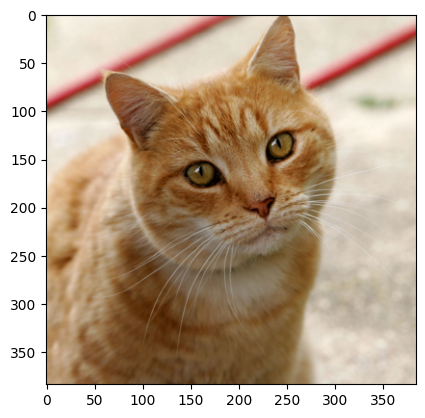

In [19]:
img = Image.open("cat.png")
print(f"Original image size: {img.size}")

img = img.resize((384, 384))
print(f"Resized image size: {img.size}")

plt.imshow(img)

In [20]:
model = torch.load("model.pth")
model.eval()

<ipython-input-20-f9b961703bea>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("model.pth")


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (head): Linear(in_features=768, out_features=1000, bi

In [21]:
img = (np.array(img)/ 128) - 1 # in the range -1, 1
print(img)

[[[ 0.6875     0.6171875  0.375    ]
  [ 0.7109375  0.640625   0.3984375]
  [ 0.7265625  0.65625    0.4140625]
  ...
  [ 0.8203125  0.7265625  0.6484375]
  [ 0.8125     0.734375   0.6484375]
  [ 0.8046875  0.734375   0.6484375]]

 [[ 0.6875     0.6171875  0.375    ]
  [ 0.7109375  0.640625   0.3984375]
  [ 0.7265625  0.65625    0.4140625]
  ...
  [ 0.8203125  0.7421875  0.6328125]
  [ 0.8125     0.7421875  0.6328125]
  [ 0.8203125  0.7421875  0.6328125]]

 [[ 0.6796875  0.609375   0.359375 ]
  [ 0.6953125  0.6328125  0.375    ]
  [ 0.7265625  0.65625    0.4140625]
  ...
  [ 0.828125   0.75       0.65625  ]
  [ 0.8203125  0.7421875  0.640625 ]
  [ 0.8359375  0.7265625  0.640625 ]]

 ...

 [[ 0.4609375  0.2265625 -0.0546875]
  [ 0.484375   0.25      -0.0234375]
  [ 0.4921875  0.2578125 -0.0078125]
  ...
  [ 0.7421875  0.640625   0.515625 ]
  [ 0.734375   0.640625   0.515625 ]
  [ 0.7265625  0.6328125  0.5078125]]

 [[ 0.453125   0.2109375 -0.0625   ]
  [ 0.4765625  0.2265625 -0.0390625]


In [22]:
k = 10
inp = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).to(torch.float32)
logits = model(inp)
probs = logits.softmax(dim=-1)

top_probs, top_ixs = probs[0].topk(k)

In [23]:
for i, (ix_, prob_) in enumerate(zip(top_ixs, top_probs)):
  ix = ix_.item()
  prob = prob_.item()
  cls_name = imagenet_labels[ix].strip()
  print(f"{i+1}: {cls_name:<45} | {prob:.4f}")

1: tiger_cat                                     | 0.5996
2: Egyptian_cat                                  | 0.2693
3: tabby, tabby_cat                              | 0.0929
4: lynx, catamount                               | 0.0192
5: Persian_cat                                   | 0.0008
6: Siamese_cat, Siamese                          | 0.0006
7: broom                                         | 0.0005
8: coil, spiral, volute, whorl, helix            | 0.0004
9: Angora, Angora_rabbit                         | 0.0003
10: ping-pong_ball                                | 0.0003


# Dataset

In [24]:
!pip install kaggle

In [25]:
! mkdir ~/.kaggle
! cp /content/drive/MyDrive/Kaggle_API/kaggle.json ~/.kaggle/kaggle.json
! chmod 600 ~/.kaggle/kaggle.json

In [26]:
!kaggle competitions download Digit-Recognizer -p /content/dataset

 85% 13.0M/15.3M [00:01<00:00, 14.1MB/s]
100% 15.3M/15.3M [00:01<00:00, 9.23MB/s]


In [27]:
with zipfile.ZipFile("/content/dataset/Digit-Recognizer.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

# Hyper parameters

In [59]:
random_seed = 42
batch_size = 512
epochs = 40
learning_rate = 1e-4
num_classes = 10
dropout = 0.001
hidden_dim = 768
adam_weight_decay = 0
adam_betas = (0.9, 0.999)

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [30]:
custom_config = {
    "img_size": 28,
    "in_chans": 1,
    "patch_size": 4,
    "embed_dim": 16, # (patch_size**2)*in_chans
    "depth": 4,
    "n_heads": 8,
    "qkv_bias": True,
    "mlp_ratio": 4,
}

In [31]:
model = VisionTransformer(**custom_config)

In [32]:
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Train Test Split

In [33]:
train_df = pd.read_csv('/content/dataset/train.csv')
test_df = pd.read_csv('/content/dataset/test.csv')

In [34]:
print(train_df.shape)
print(test_df.shape)

(42000, 785)
(28000, 784)


In [35]:
train_df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [36]:
test_df.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [37]:
train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=random_seed, shuffle=True)

In [38]:
class MNISTTrainDataset(Dataset):
  def __init__(self, images, labels, indices):
    self.images = images
    self.labels = labels
    self.indices = indices
    self.transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomRotation(15), # Data Augmentation
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

  def __len__(self):
    return len(self.images)

  def __getitem__(self, idx):
    image = self.images[idx].reshape((28, 28)).astype(np.uint8)
    label = self.labels[idx]
    index = self.indices[idx]
    image = self.transform(image)
    return {"image": image, "label": label, "index": index}

In [39]:
class MNISTValDataset(Dataset):
  def __init__(self, images, labels, indices):
    self.images = images
    self.labels = labels
    self.indices = indices
    self.transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

  def __len__(self):
    return len(self.images)

  def __getitem__(self, idx):
    image = self.images[idx].reshape((28, 28)).astype(np.uint8)
    label = self.labels[idx]
    index = self.indices[idx]
    image = self.transform(image)
    return {"image": image, "label": label, "index": index}

37800
{'image': tensor([[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0

<Figure size 640x480 with 0 Axes>

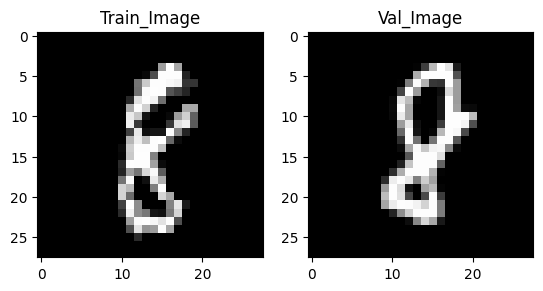

In [40]:
plt.figure()
f, axarr = plt.subplots(1, 2)

train_dataset = MNISTTrainDataset(train_df.iloc[:, 1:].values.astype(np.uint8), train_df.iloc[:, 0].values, train_df.index.values)
print(len(train_dataset))
print(train_dataset[0])
axarr[0].imshow(train_dataset[0]['image'].squeeze(), cmap='gray')
axarr[0].set_title("Train_Image")
print("-"*30)

val_dataset = MNISTValDataset(val_df.iloc[:, 1:].values.astype(np.uint8), val_df.iloc[:, 0].values, val_df.index.values)
print(len(val_dataset))
print(val_dataset[0])
axarr[1].imshow(val_dataset[0]['image'].squeeze(), cmap='gray')
axarr[1].set_title("Val_Image")
print("-"*30)

# Data Loader

In [41]:
train_dataloader =  DataLoader(train_dataset,
                               batch_size=batch_size,
                               shuffle=True)
val_dataloader =  DataLoader(val_dataset,
                             batch_size=batch_size,
                             shuffle=True)

# Train

In [45]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), betas = adam_betas, lr=learning_rate, weight_decay = adam_weight_decay)

In [46]:
train_loss_list = []
val_loss_list = []

In [60]:
start = timeit.default_timer()

for epoch in tqdm(range(epochs), position=0, leave=True):
  model.train().to(device)
  train_labels = []
  train_preds = []
  train_running_loss = 0
  for idx, img_label in enumerate(tqdm(train_dataloader, position=0, leave=True)):
    img = img_label['image'].float().to(device)
    label = img_label['label'].type(torch.uint8).to(device)
    y_pred = model(img)
    y_pred_label = torch.argmax(y_pred, dim=1)

    train_labels.extend(label.cpu().detach()) # Store in cpu so as to not overfill gpu
    train_preds.extend(y_pred_label.cpu().detach())

    loss = criterion(y_pred, label)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_running_loss += loss.item()
  train_loss = train_running_loss / (idx+1)
  train_loss_list.append(train_loss)

  model.eval()
  val_labels = []
  val_preds = []
  val_running_loss = 0
  with torch.no_grad():
    for idx, img_label in enumerate(tqdm(val_dataloader, position=0, leave=True)):
      img = img_label['image'].float().to(device)
      label = img_label['label'].type(torch.uint8).to(device)
      y_pred = model(img)
      y_pred_label = torch.argmax(y_pred, dim=1)

      val_labels.extend(label.cpu().detach())
      val_preds.extend(y_pred_label.cpu().detach())

      loss = criterion(y_pred, label)
      val_running_loss += loss.item()
  val_loss = val_running_loss / (idx+1)
  val_loss_list.append(val_loss)

  print("-"*30)
  print(f"Train Loss Epoch {epoch+1}: {train_loss:.4f}")
  print(f"Val Loss Epoch {epoch+1}: {val_loss:.4f}")
  print(f"Training accuracy: {sum (1 for x,y in zip(train_preds, train_labels) if x==y) / len(train_labels):.4f}")
  print(f"Validation accuracy: {sum (1 for x,y in zip(val_preds, val_labels) if x==y) / len(val_labels):.4f}")
  print("-"*30)

stop = timeit.default_timer()

100%|██████████| 9/9 [00:00<00:00,  9.20it/s]


------------------------------
Train Loss Epoch 1: 4.5120
Val Loss Epoch 1: 4.3731


  2%|▎         | 1/40 [00:18<12:12, 18.77s/it]

Training accuracy: 0.2430
Validation accuracy: 0.2448
------------------------------


100%|██████████| 9/9 [00:00<00:00, 11.91it/s]


...

Training accuracy: 0.8357
Validation accuracy: 0.8721
------------------------------


100%|██████████| 9/9 [00:00<00:00,  9.43it/s]


------------------------------
Train Loss Epoch 40: 0.6256
Val Loss Epoch 40: 0.5717


100%|██████████| 40/40 [12:38<00:00, 18.97s/it]

Training accuracy: 0.8409
Validation accuracy: 0.8612
------------------------------


In [61]:
print(f'Training Time: {stop-start:.2f}s')

Training Time: 758.86s


# Visualization

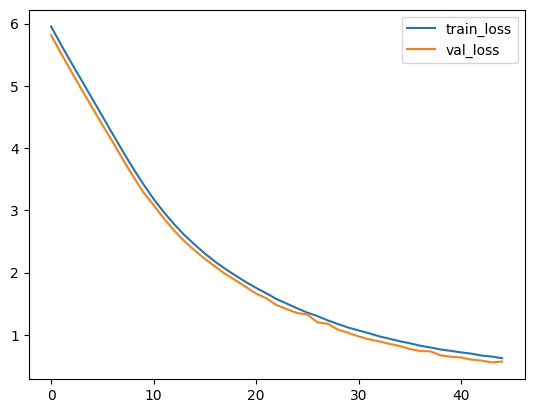

In [62]:
plt.plot(train_loss_list)
plt.plot(val_loss_list)
plt.legend(["train_loss", "val_loss"])
plt.show()

# Saved the trained model and its weights

In [63]:
torch.save(model_custom.state_dict(), "trained_weights.pth")
torch.save(model_custom, "trained_model.pth")